In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sqlalchemy import create_engine

In [2]:
df1=pd.read_csv(r'C:\Users\QC#\Downloads\dataset_olympics.csv')
df2=pd.read_csv(r'C:\Users\QC#\Downloads\noc_region.csv')

In [3]:
df1

,ID,Name,Sex,Age,Height,Weight,Team,NOC,Games,Year,Season,City,Sport,Event,Medal
0,1,A Dijiang,M,24.0,180.0,80.0,China,CHN,1992 Summer,1992,Summer,Barcelona,Basketball,Basketball Men's Basketball,NaN
1,2,A Lamusi,M,23.0,170.0,60.0,China,CHN,2012 Summer,2012,Summer,London,Judo,Judo Men's Extra-Lightweight,NaN
2,3,Gunnar Nielsen Aaby,M,24.0,NaN,NaN,Denmark,DEN,1920 Summer,1920,Summer,Antwerpen,Football,Football Men's Football,NaN
3,4,Edgar Lindenau Aabye,M,34.0,NaN,NaN,Denmark/Sweden,DEN,1900 Summer,1900,Summer,Paris,Tug-Of-War,Tug-Of-War Men's Tug-Of-War,Gold
4,5,Christine Jacoba Aaftink,F,21.0,185.0,82.0,Netherlands,NED,1988 Winter,1988,Winter,Calgary,Speed Skating,Speed Skating Women's 500 metres,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
69995,35656,Stuart Fitzsimmons,M,19.0,NaN,NaN,Great Britain,GBR,1976 Winter,1976,Winter,Innsbruck,Alpine Skiing,Alpine Skiing Men's Giant Slalom,NaN
69996,35656,Stuart Fitzsimmons,M,19.0,NaN,NaN,Great Britain,GBR,1976 Winter,1976,Winter,Innsbruck,Alpine Skiing,Alpine Skiing Men's Slalom,NaN
69997,35657,"David Thomas ""Dave"" Fitzsimons",M,26.0,170.0,65.0,Australia,AUS,1976 Summer,1976,Summer,Montreal,Athletics,"Athletics Men's 10,000 metres",NaN
69998,35657,"David Thomas ""Dave"" Fitzsimons",M,30.0,170.0,65.0,Australia,AUS,1980 Summer,1980,Summer,Moskva,Athletics,"Athletics Men's 5,000 metres",NaN


In [4]:
df1.duplicated().sum()

np.int64(383)

In [55]:
df1.drop_duplicates()

,ID,Name,Sex,Age,Height,Weight,Team,NOC,Games,Year,Season,City,Sport,Event,Medal
0,1,A Dijiang,M,24.0,180.0,80.0,China,CHN,1992 Summer,1992,Summer,Barcelona,Basketball,Basketball Men's Basketball,No Medal
1,2,A Lamusi,M,23.0,170.0,60.0,China,CHN,2012 Summer,2012,Summer,London,Judo,Judo Men's Extra-Lightweight,No Medal
2,3,Gunnar Nielsen Aaby,M,24.0,175.0,70.0,Denmark,DEN,1920 Summer,1920,Summer,Antwerpen,Football,Football Men's Football,No Medal
3,4,Edgar Lindenau Aabye,M,34.0,175.0,70.0,Denmark/Sweden,DEN,1900 Summer,1900,Summer,Paris,Tug-Of-War,Tug-Of-War Men's Tug-Of-War,Gold
4,5,Christine Jacoba Aaftink,F,21.0,185.0,82.0,Netherlands,NED,1988 Winter,1988,Winter,Calgary,Speed Skating,Speed Skating Women's 500 metres,No Medal
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
69995,35656,Stuart Fitzsimmons,M,19.0,175.0,70.0,Great Britain,GBR,1976 Winter,1976,Winter,Innsbruck,Alpine Skiing,Alpine Skiing Men's Giant Slalom,No Medal
69996,35656,Stuart Fitzsimmons,M,19.0,175.0,70.0,Great Britain,GBR,1976 Winter,1976,Winter,Innsbruck,Alpine Skiing,Alpine Skiing Men's Slalom,No Medal
69997,35657,"David Thomas ""Dave"" Fitzsimons",M,26.0,170.0,65.0,Australia,AUS,1976 Summer,1976,Summer,Montreal,Athletics,"Athletics Men's 10,000 metres",No Medal
69998,35657,"David Thomas ""Dave"" Fitzsimons",M,30.0,170.0,65.0,Australia,AUS,1980 Summer,1980,Summer,Moskva,Athletics,"Athletics Men's 5,000 metres",No Medal


In [56]:
df2.duplicated().sum()

np.int64(0)

In [7]:
df1.isna().sum()

ID            0
Name          0
Sex           0
Age        2732
Height    16254
Weight    17101
Team          0
NOC           0
Games         0
Year          0
Season        0
City          0
Sport         0
Event         0
Medal     60310
dtype: int64

In [8]:
df1['Medal']=df1['Medal'].fillna('No Medal') #if we remove medal coloum we cannot compare gold_medalest with other Palyers
df1['Age']=df1['Age'].fillna(df1['Age'].median())
df1['Weight']=df1['Weight'].fillna(df1['Weight'].median())
df1['Height']=df1['Height'].fillna(df1['Height'].median())

In [9]:
df1.isnull().sum()

ID        0
Name      0
Sex       0
Age       0
Height    0
Weight    0
Team      0
NOC       0
Games     0
Year      0
Season    0
City      0
Sport     0
Event     0
Medal     0
dtype: int64

In [10]:
df2.isnull().sum()

noc_region      0
reg             3
notes         209
dtype: int64

In [11]:
df2

,noc_region,reg,notes
0,AFG,Afghanistan,NaN
1,AHO,Curacao,Netherlands Antilles
2,ALB,Albania,NaN
3,ALG,Algeria,NaN
4,AND,Andorra,NaN
...,...,...,...
225,YEM,Yemen,NaN
226,YMD,Yemen,South Yemen
227,YUG,Serbia,Yugoslavia
228,ZAM,Zambia,NaN


In [12]:
df2['reg']=df2['reg'].fillna(df2['noc_region'])
df2.drop(columns=['notes'],inplace=True)

In [13]:
df2.isna().sum()

noc_region    0
reg           0
dtype: int64

In [14]:
df2[df2['reg']==df2['noc_region']]

,noc_region,reg
168,ROT,ROT
208,TUV,TUV
213,UNK,UNK
216,USA,USA


In [15]:
df2['reg']=df2['reg'].replace({
    'ROT':'Refugee Olymplic Team',
    'TUV':'Tuvalu',
    'UNK':'Unknown',
    'USA':'United States'})

In [16]:
df2.rename(columns={'reg':'Region'},inplace=True)
df2.rename(columns={'noc_region':'NOC'},inplace=True)

In [17]:
df_final=pd.merge(df1,df2,on='NOC',how='left')

In [18]:
df_final.isna().sum()

ID         0
Name       0
Sex        0
Age        0
Height     0
Weight     0
Team       0
NOC        0
Games      0
Year       0
Season     0
City       0
Sport      0
Event      0
Medal      0
Region    55
dtype: int64

In [19]:
df_final[df_final['Region'].isnull()]['NOC'].unique()

<StringArray>
['SGP']
Length: 1, dtype: str

In [20]:
df_final['Region']=df_final['Region'].fillna(df_final['NOC'])

In [21]:
df_final.isna().sum()

ID        0
Name      0
Sex       0
Age       0
Height    0
Weight    0
Team      0
NOC       0
Games     0
Year      0
Season    0
City      0
Sport     0
Event     0
Medal     0
Region    0
dtype: int64

In [22]:
df_final[df_final['Region']==df_final['NOC']]

,ID,Name,Sex,Age,Height,Weight,Team,NOC,Games,Year,Season,City,Sport,Event,Medal,Region
578,332,Zarinah Abdullah,F,21.0,175.0,70.0,Singapore,SGP,1992 Summer,1992,Summer,Barcelona,Badminton,Badminton Women's Singles,No Medal,SGP
579,332,Zarinah Abdullah,F,25.0,175.0,70.0,Singapore,SGP,1996 Summer,1996,Summer,Atlanta,Badminton,Badminton Women's Singles,No Medal,SGP
2719,1515,Saiyidah Aisyah Mohamed Rafa'ee,F,28.0,173.0,68.0,Singapore,SGP,2016 Summer,2016,Summer,Rio de Janeiro,Rowing,Rowing Women's Single Sculls,No Medal,SGP
7659,4264,Ang Peng Siong,M,21.0,180.0,75.0,Singapore,SGP,1984 Summer,1984,Summer,Los Angeles,Swimming,Swimming Men's 100 metres Freestyle,No Medal,SGP
7660,4264,Ang Peng Siong,M,21.0,180.0,75.0,Singapore,SGP,1984 Summer,1984,Summer,Los Angeles,Swimming,Swimming Men's 4 x 100 metres Freestyle Relay,No Medal,SGP
7661,4264,Ang Peng Siong,M,21.0,180.0,75.0,Singapore,SGP,1984 Summer,1984,Summer,Los Angeles,Swimming,Swimming Men's 100 metres Butterfly,No Medal,SGP
7662,4264,Ang Peng Siong,M,21.0,180.0,75.0,Singapore,SGP,1984 Summer,1984,Summer,Los Angeles,Swimming,Swimming Men's 4 x 100 metres Medley Relay,No Medal,SGP
7663,4264,Ang Peng Siong,M,25.0,180.0,75.0,Singapore,SGP,1988 Summer,1988,Summer,Seoul,Swimming,Swimming Men's 50 metres Freestyle,No Medal,SGP
7664,4264,Ang Peng Siong,M,25.0,180.0,75.0,Singapore,SGP,1988 Summer,1988,Summer,Seoul,Swimming,Swimming Men's 100 metres Freestyle,No Medal,SGP
7665,4264,Ang Peng Siong,M,25.0,180.0,75.0,Singapore,SGP,1988 Summer,1988,Summer,Seoul,Swimming,Swimming Men's 4 x 100 metres Freestyle Relay,No Medal,SGP


In [23]:
df_final['Region']=df_final['Region'].replace({
    'SGP':'Singapore'})

In [24]:
df_final.isna().sum()

ID        0
Name      0
Sex       0
Age       0
Height    0
Weight    0
Team      0
NOC       0
Games     0
Year      0
Season    0
City      0
Sport     0
Event     0
Medal     0
Region    0
dtype: int64

In [25]:
df_final

,ID,Name,Sex,Age,Height,Weight,Team,NOC,Games,Year,Season,City,Sport,Event,Medal,Region
0,1,A Dijiang,M,24.0,180.0,80.0,China,CHN,1992 Summer,1992,Summer,Barcelona,Basketball,Basketball Men's Basketball,No Medal,China
1,2,A Lamusi,M,23.0,170.0,60.0,China,CHN,2012 Summer,2012,Summer,London,Judo,Judo Men's Extra-Lightweight,No Medal,China
2,3,Gunnar Nielsen Aaby,M,24.0,175.0,70.0,Denmark,DEN,1920 Summer,1920,Summer,Antwerpen,Football,Football Men's Football,No Medal,Denmark
3,4,Edgar Lindenau Aabye,M,34.0,175.0,70.0,Denmark/Sweden,DEN,1900 Summer,1900,Summer,Paris,Tug-Of-War,Tug-Of-War Men's Tug-Of-War,Gold,Denmark
4,5,Christine Jacoba Aaftink,F,21.0,185.0,82.0,Netherlands,NED,1988 Winter,1988,Winter,Calgary,Speed Skating,Speed Skating Women's 500 metres,No Medal,Netherlands
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
69995,35656,Stuart Fitzsimmons,M,19.0,175.0,70.0,Great Britain,GBR,1976 Winter,1976,Winter,Innsbruck,Alpine Skiing,Alpine Skiing Men's Giant Slalom,No Medal,UK
69996,35656,Stuart Fitzsimmons,M,19.0,175.0,70.0,Great Britain,GBR,1976 Winter,1976,Winter,Innsbruck,Alpine Skiing,Alpine Skiing Men's Slalom,No Medal,UK
69997,35657,"David Thomas ""Dave"" Fitzsimons",M,26.0,170.0,65.0,Australia,AUS,1976 Summer,1976,Summer,Montreal,Athletics,"Athletics Men's 10,000 metres",No Medal,Australia
69998,35657,"David Thomas ""Dave"" Fitzsimons",M,30.0,170.0,65.0,Australia,AUS,1980 Summer,1980,Summer,Moskva,Athletics,"Athletics Men's 5,000 metres",No Medal,Australia


In [45]:
#Top 10 country by medal
real_medal=df_final[df_final['Medal']!='No Medal']
print(Top_country:=real_medal.groupby('Region')['Medal'].count().sort_values(ascending=False).head(10))

Region
United States    1561
Russia            794
Germany           756
France            660
Italy             604
UK                604
Australia         383
Sweden            365
Canada            360
Netherlands       272
Name: Medal, dtype: int64


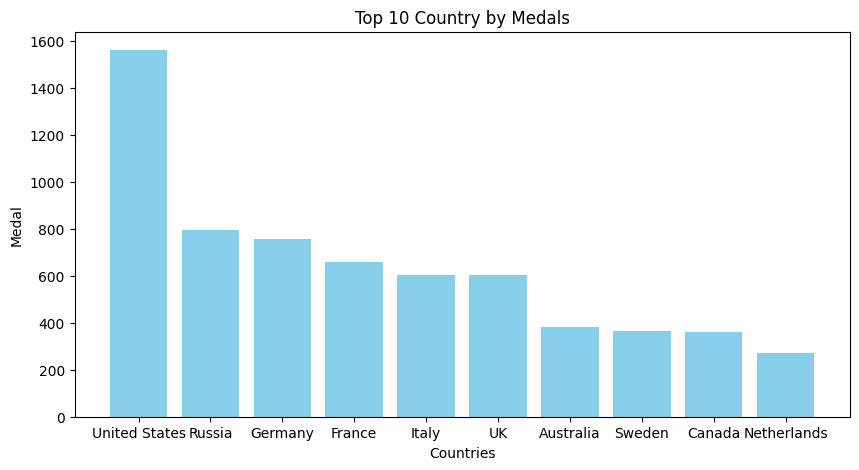

In [46]:
#Top 10 country graphical presentation
plt.figure(figsize=(10,5))
plt.bar(Top_country.index,Top_country.values,color='skyblue')
plt.title('Top 10 Country by Medals')
plt.xlabel('Countries')
plt.ylabel('Medal')
plt.show()

In [53]:
#Yearly trend of medal
real_medal.groupby(['Year','Region'])['Medal'].count().unstack().fillna(0)

Region,Algeria,Argentina,Armenia,Australia,Austria,Azerbaijan,Bahamas,Belarus,Belgium,Botswana,...,Turkey,UK,Uganda,Ukraine,United Arab Emirates,United States,Uruguay,Uzbekistan,Venezuela,Zimbabwe
Year,,,,,,,,,,,,,,,,,,,,,
1896,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,5.0,0.0,0.0,0.0,9.0,0.0,0.0,0.0,0.0
1900,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,10.0,0.0,...,0.0,43.0,0.0,0.0,0.0,18.0,0.0,0.0,0.0,0.0
1904,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,1.0,0.0,0.0,0.0,101.0,0.0,0.0,0.0,0.0
1906,0.0,0.0,0.0,2.0,1.0,0.0,0.0,0.0,6.0,0.0,...,0.0,8.0,0.0,0.0,0.0,5.0,0.0,0.0,0.0,0.0
1908,0.0,0.0,0.0,7.0,0.0,0.0,0.0,0.0,10.0,0.0,...,0.0,101.0,0.0,0.0,0.0,23.0,0.0,0.0,0.0,0.0
1912,0.0,0.0,0.0,3.0,3.0,0.0,0.0,0.0,8.0,0.0,...,0.0,41.0,0.0,0.0,0.0,22.0,0.0,0.0,0.0,0.0
1920,0.0,0.0,0.0,2.0,0.0,0.0,0.0,0.0,76.0,0.0,...,0.0,30.0,0.0,0.0,0.0,44.0,0.0,0.0,0.0,0.0
1924,0.0,2.0,0.0,8.0,4.0,0.0,0.0,0.0,20.0,0.0,...,0.0,28.0,0.0,0.0,0.0,51.0,3.0,0.0,0.0,0.0
1928,0.0,11.0,0.0,2.0,4.0,0.0,0.0,0.0,2.0,0.0,...,0.0,12.0,0.0,0.0,0.0,39.0,10.0,0.0,0.0,0.0


In [28]:
#Participation Trend
Participation=df_final.drop_duplicates(['Year','Region'])['Year'].value_counts().reset_index().head(10)
print(Participation)

   Year  count
0  2012    179
1  2016    179
2  1996    177
3  2008    176
4  2004    176
5  2000    172
6  1992    151
7  1988    150
8  1984    139
9  1972    109


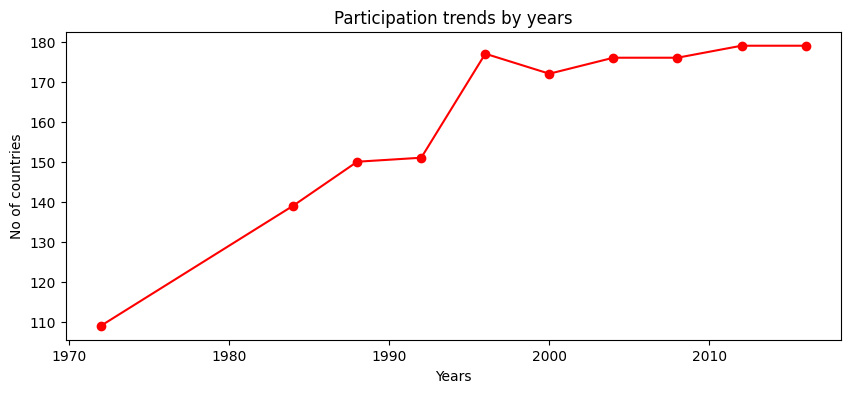

In [29]:
Participation=Participation.sort_values('Year')
plt.figure(figsize=(10,4))
plt.plot(Participation['Year'],Participation['count'],marker='o',color='red')
plt.title('Participation trends by years')
plt.xlabel('Years')
plt.ylabel('No of countries')
plt.show()

In [30]:
#Top Athletes
medals=df_final[df_final['Medal'].isin(['Gold','Silver','Bronze'])]
top_athletes=medals.groupby('Name')['Medal'].count().sort_values(ascending=False).head(10)
print(top_athletes)

Name
Nikolay Yefimovich Andrianov       15
Ole Einar Bjrndalen                13
Birgit Fischer-Schmidt             12
Natalie Anne Coughlin (-Hall)      12
Vra slavsk (-Odloilov)             11
Viktor Ivanovych Chukarin          11
Matthew Nicholas "Matt" Biondi     11
Aleksandr Nikolayevich Dityatin    10
Stefania Belmondo                  10
Raymond Clarence "Ray" Ewry        10
Name: Medal, dtype: int64


In [31]:
#Top contry  with Medals
medal_types=medals.groupby(['Region','Medal']).size().unstack().fillna(0)
medal_types.sort_values('Gold',ascending=False).head(5)

Medal,Bronze,Gold,Silver
Region,,,
United States,366.0,747.0,448.0
Russia,247.0,315.0,232.0
Germany,249.0,261.0,246.0
Italy,194.0,217.0,193.0
UK,186.0,211.0,207.0


In [32]:
gender_participation=df_final.drop_duplicates(['Name','Region'])['Sex'].value_counts()

In [33]:
print(gender_participation)

Sex
M    27411
F     8358
Name: count, dtype: int64


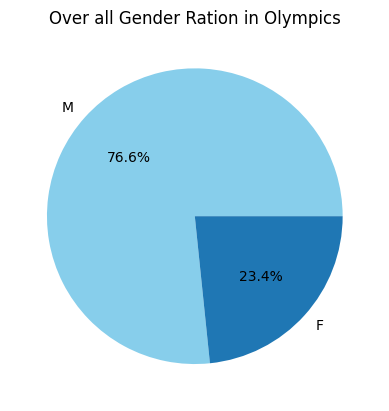

In [62]:
gender_participation.plot(kind='pie',autopct='%1.1f%%',colors=['skyblue','#1f77b4'])
plt.title('Over all Gender Ration in Olympics')
plt.show()

In [35]:
gender_trend=df_final.drop_duplicates(['Name','Year']).groupby(['Year','Sex']).size().unstack().fillna(0)
gender_trend=gender_trend.sort_index()

In [36]:
print(gender_trend)

Sex        F       M
Year                
1896     0.0    34.0
1900     8.0   423.0
1904     1.0   166.0
1906     1.0   202.0
1908    11.0   567.0
1912    19.0   590.0
1920    25.0   772.0
1924    56.0  1004.0
1928    81.0   909.0
1932    58.0   533.0
1936   118.0  1208.0
1948   139.0  1317.0
1952   144.0  1374.0
1956   115.0   955.0
1960   169.0  1468.0
1964   207.0  1343.0
1968   265.0  1493.0
1972   304.0  1807.0
1976   372.0  1476.0
1980   367.0  1283.0
1984   466.0  1770.0
1988   638.0  1983.0
1992   779.0  2113.0
1994   124.0   296.0
1996   849.0  1826.0
1998   183.0   327.0
2000  1041.0  1754.0
2002   188.0   347.0
2004  1029.0  1689.0
2006   207.0   358.0
2008  1122.0  1670.0
2010   207.0   314.0
2012  1198.0  1569.0
2014   237.0   368.0
2016  1292.0  1711.0


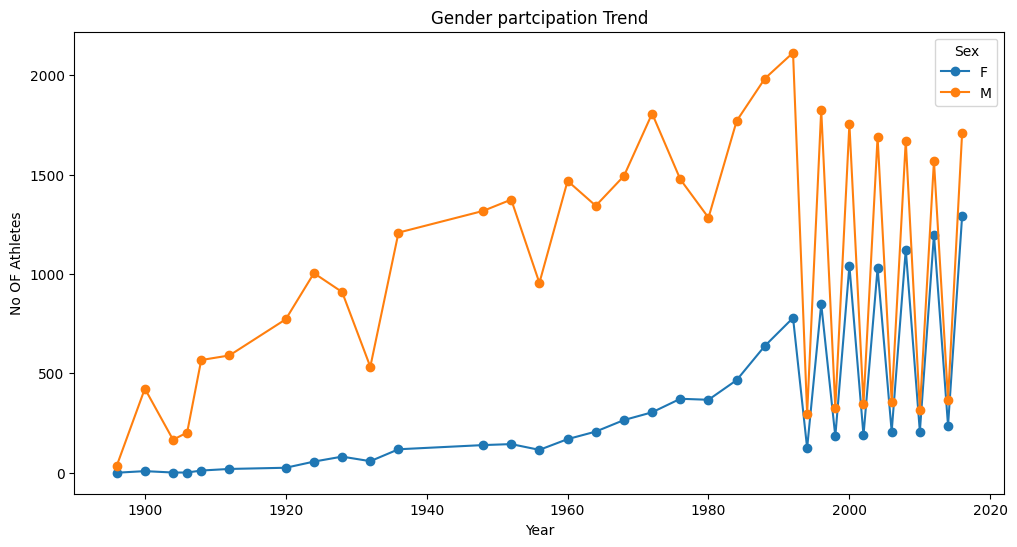

In [37]:
gender_trend.plot(kind='line',figsize=(12,6),marker='o')
plt.title('Gender partcipation Trend')
plt.xlabel('Year')
plt.ylabel('No OF Athletes')
plt.show()

In [38]:
gender_trend_sort=df_final.drop_duplicates(['Name','Year']).groupby(['Year','Sex']).size().unstack().fillna(0)
gender_trend_sort['Total']=gender_trend_sort['M']+gender_trend['F']
gender_trend_sort=gender_trend_sort.sort_values(by='Total',ascending=False)
print(gender_trend_sort)

Sex        F       M   Total
Year                        
2016  1292.0  1711.0  3003.0
1992   779.0  2113.0  2892.0
2000  1041.0  1754.0  2795.0
2008  1122.0  1670.0  2792.0
2012  1198.0  1569.0  2767.0
2004  1029.0  1689.0  2718.0
1996   849.0  1826.0  2675.0
1988   638.0  1983.0  2621.0
1984   466.0  1770.0  2236.0
1972   304.0  1807.0  2111.0
1976   372.0  1476.0  1848.0
1968   265.0  1493.0  1758.0
1980   367.0  1283.0  1650.0
1960   169.0  1468.0  1637.0
1964   207.0  1343.0  1550.0
1952   144.0  1374.0  1518.0
1948   139.0  1317.0  1456.0
1936   118.0  1208.0  1326.0
1956   115.0   955.0  1070.0
1924    56.0  1004.0  1060.0
1928    81.0   909.0   990.0
1920    25.0   772.0   797.0
1912    19.0   590.0   609.0
2014   237.0   368.0   605.0
1932    58.0   533.0   591.0
1908    11.0   567.0   578.0
2006   207.0   358.0   565.0
2002   188.0   347.0   535.0
2010   207.0   314.0   521.0
1998   183.0   327.0   510.0
1900     8.0   423.0   431.0
1994   124.0   296.0   420.0
1906     1.0  

In [39]:
#Top 10 Sports
top_sport=df_final.drop_duplicates(['Name','Sport'])['Sport'].value_counts().head(10)
print(top_sport)

Sport
Athletics    6042
Swimming     2272
Rowing       1962
Football     1800
Cycling      1520
Boxing       1455
Shooting     1331
Sailing      1297
Wrestling    1293
Fencing      1213
Name: count, dtype: int64


In [44]:
engine=create_engine('postgresql://# GIVE OWN PATH')

In [41]:
df1.to_sql('athelet',engine,if_exists='replace',index=False)

1000

In [42]:
df2.to_sql('region',engine,if_exists='replace',index=False)

230

In [43]:
df_final.to_csv(" OLYMPIC_DATA_PB.csv",index=False)